<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2: $k$ Nearest Neighbor

### Do any four.

I did questions 1-4

In [1]:
! git clone https://github.com/nehaj2026/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 36 (delta 9), reused 6 (delta 6), pack-reused 23 (from 1)
Receiving objects: 100% (36/36), 64.98 KiB | 2.41 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()



Download complete
Extracting data files...
Data extracted


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

# Question #1 Responses

1.   Regression and classification are both predictive machine learning model techniques where each predicts a class for a new observation using historical data that the model is trained on. Regression predicts classes that are numeric/continuous. Classification predicts categorical classes.
2.   A confusion matrix allows for tracking the accuracy of a model. It lists predictions and actual classes in a matrix that allows for tracking false positives, false negatives, true positives, true negatives. With these measurements, we are able to calculate the accuracy rate of the model.
3. Accuracy is a method for evaluating the amount of correct predictions made by the model. This allows us to make decisions on whether to trust the model for decision making. Accuracy is often manually computed by summing true positives and negatives and dividing this sum by the total number of observations. Accuracy is often not sufficient because in certain cases like medical diagnoses, we care a lot more if an observation is positive, so we are extremely wary about false negatives because they can put patients' lives at risk.
4. Root mean squared error is a measure of the magnitude of prediction errors made in regression models. It increases sensitivity to outliers by disproportionately penalizing them due squaring errors. Overall, it measures the average difference between the model's predicted and actual values and serves as a measure of accuracy.
5. Overfitting refers to training the model extensively in a manner that causes it to codify noise in the training set as generalizable rules for prediction. It has high accuracy on training data and low accuracy on predicting new observations. Underfitting refers to under-training the model in a manner that does not allow the model to learn key patterns to create proper and accurate generalizable rules. It has low accuracy on training data and on predicting new observations.
6. By splitting training and testing data, the model will be tested for accuracy on new data that it has not seen before, which provides a more accurate assessment of model performance. K determines the sensitivity to noise and RMSE is a measure for accuracy. By leveraging these hyperparameters, it prevents overfitting to noise, balances bias, and variance to produce the ideal model which minimalizes risk / overfitting.
7. The strengths of the class label prediction is this allows for immediate action to be taken. For example, if you are predicting whether someone has the flu or not, you can have a quick takeaway to guide the patient. The cons are that for other examples it causes a very rigid bar for class, like accusing a student of using generative AI, this method would just provide a yes/no, even if the student had a 50.1% probability of having used AI. The pros of having the probability distribution are that it allows us to understand the confidence the model has in making its decision. So, for example if we are predicting if a patient has a terminal diagnosis, it is really important we know how confident the model is before changing that patient's life forever. The cons of this approach are that it requires more interpretation that might slow down decision making if quick action needs to be made.



**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [18]:
#Question 2.1 (Part 1): Load data and EDA
df = pd.read_csv('/content/data/land_mines.csv')
df.describe()


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [19]:
df['mine_type'].value_counts(normalize = True).sort_index()

,proportion
mine_type,
1,0.210059
2,0.207101
3,0.195266
4,0.195266
5,0.192308


<Axes: xlabel='voltage', ylabel='height'>

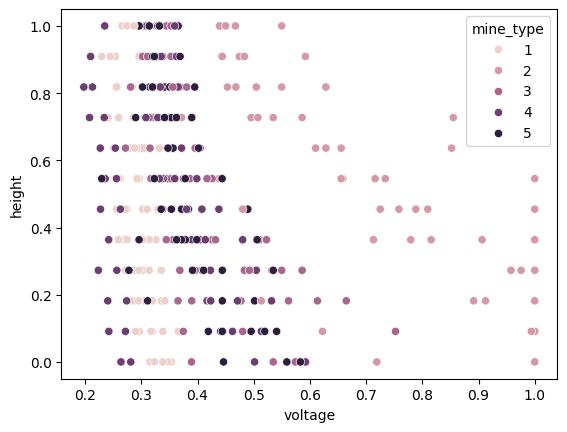

In [20]:
sns.scatterplot(data = df, x = 'voltage', y = 'height', hue = 'mine_type')

# Question 2.1 (Part 2): EDA trends

Voltage has a lower mean and standard deviation/variance than  the other predictors. Mine_type 2 has a higher voltage than other mine_types, as seen in the scatterplot. There is also significant overlap of mine_types in the scatterplot.

In [23]:
#Question 2.2: 50/50 train test split

def minmax(X):
    u = (X-min(X))/(max(X)-min(X))
    return u

X = df[['voltage','height','soil']]
y = df['mine_type']
u = X.apply(minmax)

u_train, u_test, y_train, y_test = train_test_split(u, y, test_size = 0.5, stratify = y, random_state = 1)

In [27]:
#Question 2.3: Building knn classifier
from sklearn.metrics import accuracy_score

k_selection = list(range(1,100))
accuracies = []

for k in k_selection:
  model = KNeighborsClassifier(n_neighbors = k)
  model = model.fit(u_train,y_train)
  y_hat = model.predict(u_test)
  acc = accuracy_score(y_test,y_hat)
  accuracies.append(acc)

k = k_selection[accuracies.index(max(accuracies))]
model = KNeighborsClassifier(n_neighbors = k)
model = model.fit(u_train,y_train)

# I chose k by training and testing the model using the 50/50 split to discern the hyperparameter k that maximizes accuracy for the test set predictions.

In [30]:
#Question 2.4: Confusion table
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[31,  0,  2,  2,  0],
       [ 4, 22,  4,  0,  5],
       [24,  2,  5,  1,  1],
       [25,  0,  7,  1,  0],
       [22,  1,  3,  4,  3]])

In [31]:
accuracy = accuracy_score(y_test,y_hat)
print(accuracy)

0.3668639053254438


The overall accuracy was 36.69%. While this at first appears low, it is still better than a random gues (20%). In terms of a per class split, mine_type 1 and 2 were predicted with much higher accuracy than any of the other mine_types. In particular, mine_type 4 had the lowest accuracy (the least of 35 observations accuractely predicted).

# Question 2.5
The model has significantly higher accuracy for mine_type 1 and 2 than any other mine_type. For both of these mine_types, I reccommend that the model is used to supplement human decision making. Especially since removing land mines may cause the loss of life if proper precations are not taken and the mine_type is not properly identified. The poor classification abilities of the model mean that it should not be used as the sole source of decision making, only as a preliminary tool to evaluate the mine_type.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [9]:
#Question 3.1: Load csv and eda
df1 = pd.read_csv('/content/data/USA_cars_datasets.csv')
df1 = df1[['price','year','mileage']]

df1.isnull().sum()
# There are no NAs to handle

df1.head()
df1.shape


(2499, 3)

In [ ]:
#Question 3.2: maxmin normalize

def minmax(X):
    u = (X-min(X))/(max(X)-min(X))
    return u

df1['year'] = minmax(df1['year'])
df1['mileage'] = minmax(df1['mileage'])

In [11]:
#Question 3.3: train test split
X = df1[['year','mileage']]
y = df1['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

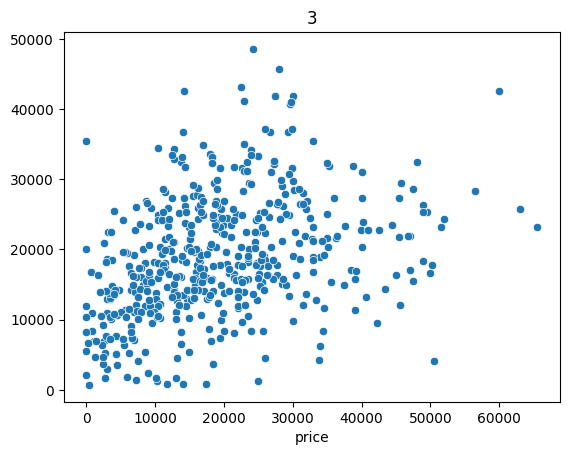

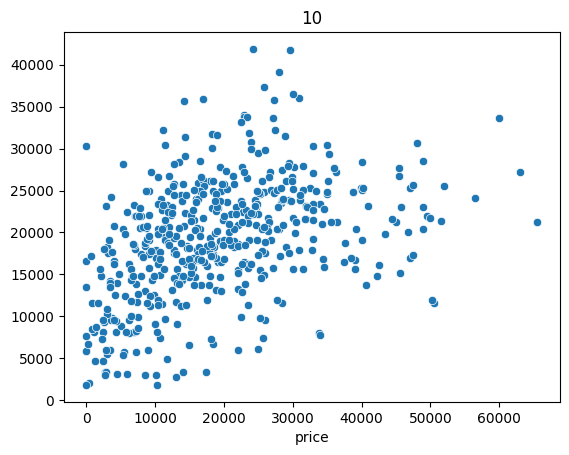

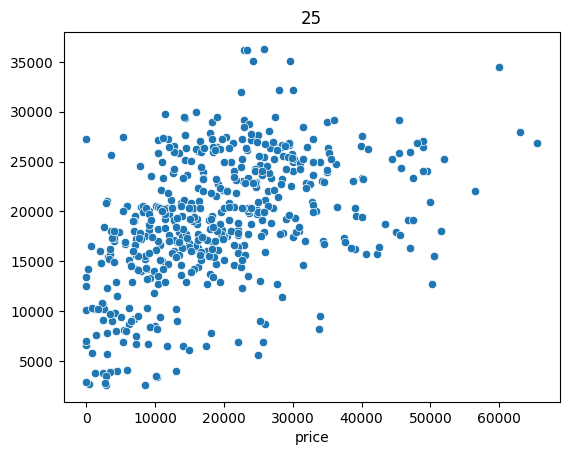

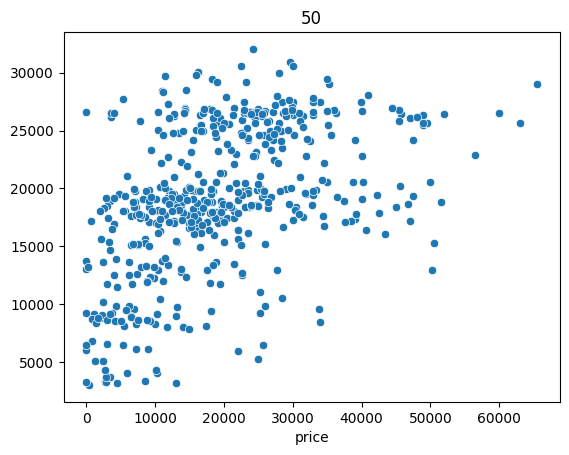

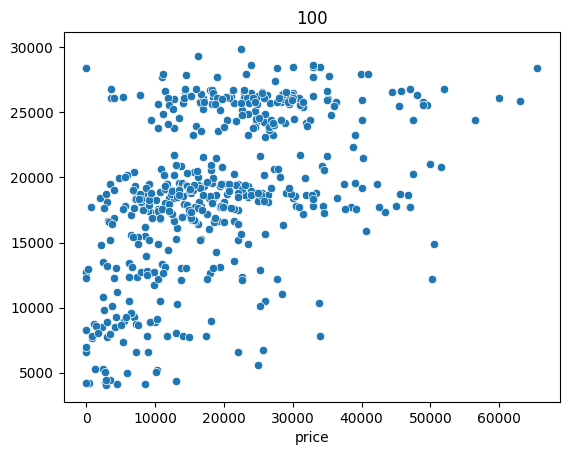

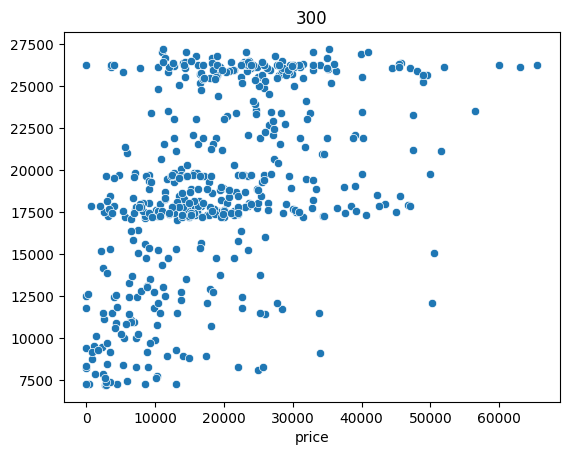

In [13]:
#Question 3.4: knn models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
k_selection = [3,10,25,50,100,300]
mse = []

for k in k_selection:
  model = KNeighborsRegressor(n_neighbors = k)
  model = model.fit(X_train,y_train)
  y_hat = model.predict(X_test)
  mse.append(mean_squared_error(y_test, y_hat))

  sns.scatterplot(x = y_test, y = y_hat)
  plt.title(str(k))
  plt.show()

#Part 2: k patterns:
  # As k increases, the predictions shrink closer to the mean price. This is because as k is extremely large, the model is underfitting the data, causing the predictions to compress horizontally to the mean and reducing variance.

In [17]:
#Question 3.5: optimal k
k = k_selection[mse.index(min(mse))]
k

# The optimal k is 100 as this k minimizes the mean square error and provides the best bias-variance tradeoff.

100

#Question 3.6
As k increased, the predictions were smoother and concentrated around the mean. At these larger values of k, the model underfits the data since the the model did not sufficiently learn what drove variations in car prices. As k was smaller, there was overfitting occuring since the model incorporated noise from the training set, which led to high variance.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [22]:
#Question 4.1
df2 = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')
df2.isnull().sum()
# There are no NAs to handle
df2 = df2.drop(columns = 'time')
df2.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [26]:
#Question 4.2: correlation matrix
df2.corr()
df2.corr()['DEATH_EVENT'].sort_values(ascending=False)

# The variables most strongly associated with DEATH_EVENT are serum_creatinine, age, and high_blood_pressure because they have the largest positive correlation.

,DEATH_EVENT
DEATH_EVENT,1.000000
serum_creatinine,0.294278
age,0.253729
high_blood_pressure,0.079351
anaemia,0.066270
creatinine_phosphokinase,0.062728
diabetes,-0.001943
sex,-0.004316
smoking,-0.012623
platelets,-0.049139


In [34]:
#Question 4.3: summary table
print(df2.groupby('anaemia')['DEATH_EVENT'].value_counts(normalize = True))
print(df2.groupby('diabetes')['DEATH_EVENT'].value_counts(normalize = True))
print(df2.groupby('high_blood_pressure')['DEATH_EVENT'].value_counts(normalize = True))
print(df2.groupby('sex')['DEATH_EVENT'].value_counts(normalize = True))
print(df2.groupby('smoking')['DEATH_EVENT'].value_counts(normalize = True))

#Proportion of deaths are higher for the dummy variables anaemia and high_blood_pressure

anaemia  DEATH_EVENT
0        0              0.705882
         1              0.294118
1        0              0.643411
         1              0.356589
Name: proportion, dtype: float64
diabetes  DEATH_EVENT
0         0              0.678161
          1              0.321839
1         0              0.680000
          1              0.320000
Name: proportion, dtype: float64
high_blood_pressure  DEATH_EVENT
0                    0              0.706186
                     1              0.293814
1                    0              0.628571
                     1              0.371429
Name: proportion, dtype: float64
sex  DEATH_EVENT
0    0              0.676190
     1              0.323810
1    0              0.680412
     1              0.319588
Name: proportion, dtype: float64
smoking  DEATH_EVENT
0        0              0.674877
         1              0.325123
1        0              0.687500
         1              0.312500
Name: proportion, dtype: float64


In [59]:
#Question 4.4: matrix X of variables predictive of death
X = df2[['serum_creatinine', 'age', 'ejection_fraction', 'anaemia']]
y = df2['DEATH_EVENT']
X.head()

# I selected serum_creatinine and age because of them having the strongest positive correlation with DEATH_EVENT.
# I selected ejection_fraction because of it having the strongest negative correlation with DEATH_EVENT
# I selected anaemia because of the summary table and the increase in proportion of deaths when anaemia = 1

,serum_creatinine,age,ejection_fraction,anaemia
0,1.9,75.0,20,0
1,1.1,55.0,38,0
2,1.3,65.0,20,0
3,1.9,50.0,20,1
4,2.7,65.0,20,1


In [60]:
#Question 4.5: maxmin of X
def minmax(X):
    u = (X-min(X))/(max(X)-min(X))
    return u

X = X.apply(minmax)
X.head()

,serum_creatinine,age,ejection_fraction,anaemia
0,0.157303,0.636364,0.090909,0.0
1,0.067416,0.272727,0.363636,0.0
2,0.089888,0.454545,0.090909,0.0
3,0.157303,0.181818,0.090909,1.0
4,0.247191,0.454545,0.090909,1.0


In [61]:
#Question 4.6: train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 1)

In [57]:
#Question 7: optimal number of neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_selection = list(range(1,100))
accuracies = []
for k in k_selection:
  model = KNeighborsClassifier(n_neighbors = k)
  model = model.fit(X_train,y_train)
  y_hat = model.predict(X_test)
  acc = accuracy_score(y_test,y_hat)
  accuracies.append(acc)

k = k_selection[accuracies.index(max(accuracies))]
k
# The optimal number of neighbors is at k=11 because it maximizes the test accuracy.

11

In [58]:
#Question 8 (Part 1): re-doing steps 5-7
New_X = df2.drop(columns = ['DEATH_EVENT']) #Note: I already dropped time in Q4.1
New_X = New_X.apply(minmax)
New_y = df2['DEATH_EVENT']

X_New_train, X_New_test, y_New_train, y_New_test = train_test_split(New_X, New_y, test_size = 0.2, random_state = 1)

k_selection = list(range(1,100))
new_mse = []

for k in k_selection:
  model = KNeighborsClassifier(n_neighbors = k)
  model = model.fit(X_New_train,y_New_train)
  y_hat = model.predict(X_New_test)
  mse = mean_squared_error(y_New_test,y_hat)
  new_mse.append(mse)

k = k_selection[new_mse.index(min(new_mse))]
k
# Optimal k is 4

optimal_new_mse = min(new_mse)
optimal_new_mse
# lowest mse is 0.217


0.21666666666666667

In [63]:
#Question 8 (Part 2): Orginal model mse

k_selection = list(range(1,100))
mse = []

for k in k_selection:
  model = KNeighborsClassifier(n_neighbors = k)
  model = model.fit(X_train,y_train)
  y_hat = model.predict(X_test)
  mse.append(mean_squared_error(y_test, y_hat))

k = k_selection[mse.index(min(mse))]
k
# Orginal k is 11


og_mse = min(mse)
og_mse
# Original mse is 0.15

11

The mse of the original model where I selected the predictors has a lower mse of 0.15 in comparison the other model's mse of 0.217. So, I would prefer to use my original model because it has the lowest mse (lowest mean square error and highest accuracy).

In [67]:
#Question 8 (Part 3): RMSE
rmse_orginal = np.sqrt(og_mse)
rmse_new = np.sqrt(optimal_new_mse)
print(rmse_orginal)
print(rmse_new)

# My original rmse outperforms the new model rmse because my model had a lower rmse and it generalizes better to unseen data.
# A model with more variables does not always perform better. As seen in this case, the new model with more variables actually performed worse due to the added noise in the model.

0.3872983346207417
0.4654746681256314


**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)